# Clinical Data Summary

**Dataset:** `2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv`

Explores columns with <50% missing data and survival endpoint statistics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv(
    "../../data/Clinical/2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
)
print(f"Shape: {df.shape}  |  Patients: {df['SID'].notna().sum()}")

Shape: (70, 189)  |  Patients: 69


## Missingness overview

In [ ]:
null_pct = (df.isna().sum() / len(df) * 100).sort_values()
useful = null_pct[null_pct < 50]
print(f"Columns <50% missing: {len(useful)} / {len(df.columns)}")
print(useful.round(1).to_string())

Columns <50% missing: 35 / 189
SID                                          1.4
Number of Lesions (99 = Diffuse Disease)     1.4
Max. Diameter of Largest Lesion              1.4
BCLC Stage                                   1.4
moderate_grade                               1.4
Date 1. Session                              1.4
Intention-To-Treat (ITT)                     1.4
ECOG Performance Status                      1.4
Safety Population (SP)                       1.4
OS_central                                   1.4
TTR_central                                  1.4
TTR_central_event                            1.4
RFS_central                                  1.4
RFS_central_event                            1.4
grade_label                                  1.4
Per Protocol Population (PP)                 1.4
HCC Etiology: NASH                           1.4
poor_grade                                   1.4
Sex                                          1.4
HCC Etiology: Alcohol                 

## Demographics

In [ ]:
print("=== Age ===")
print(df["Age"].describe().round(2))

print("\n=== Sex (1=Male, 2=Female) ===")
print(df["Sex"].value_counts().rename({1.0: "Male", 2.0: "Female"}))

print("\n=== ECOG Performance Status ===")
print(df["ECOG Performance Status"].value_counts())

=== Age ===
count    69.00
mean     62.77
std      11.64
min      27.70
25%      56.40
50%      64.70
75%      70.00
max      88.20
Name: Age, dtype: float64

=== Sex (1=Male, 2=Female) ===
Sex
Male      60
Female     9
Name: count, dtype: int64

=== ECOG Performance Status ===
ECOG Performance Status
0.0    69
Name: count, dtype: int64


## HCC Etiology

Hepatitis B: 16 (23.2%)
Hepatitis C: 15 (21.7%)
Alcohol: 18 (26.1%)
NASH: 10 (14.5%)


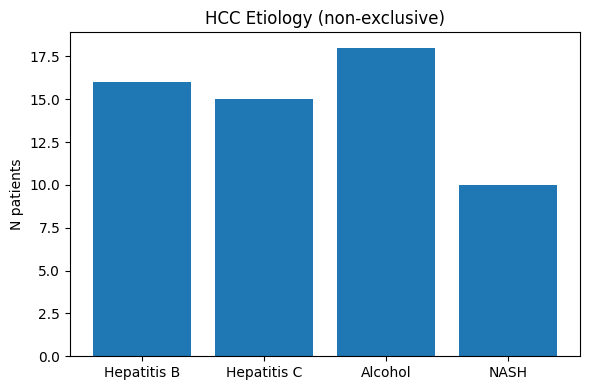

In [ ]:
etiology_cols = [
    "HCC Etiology: Hepatitis B",
    "HCC Etiology: Hepatitis C",
    "HCC Etiology: Alcohol",
    "HCC Etiology: NASH",
]
etiology_labels = ["Hepatitis B", "Hepatitis C", "Alcohol", "NASH"]

n_valid = df[etiology_cols[0]].notna().sum()
counts = [int(df[c].sum()) for c in etiology_cols]
for label, n in zip(etiology_labels, counts):
    print(f"{label}: {n} ({100 * n / n_valid:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(etiology_labels, counts)
ax.set_ylabel("N patients")
ax.set_title("HCC Etiology (non-exclusive)")
plt.tight_layout()
plt.show()

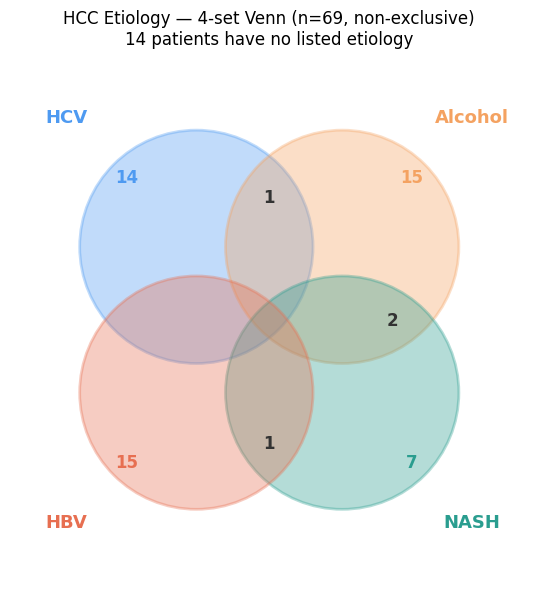

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# compute exclusive counts
cols = [
    "HCC Etiology: Hepatitis B",
    "HCC Etiology: Hepatitis C",
    "HCC Etiology: Alcohol",
    "HCC Etiology: NASH",
]
sub = df[cols].dropna().astype(int)
sub.columns = ["HBV", "HCV", "Alcohol", "NASH"]


def excl(have, not_have):
    mask = (sub[list(have)] == 1).all(axis=1)
    if not_have:
        mask &= (sub[list(not_have)] == 0).all(axis=1)
    return int(mask.sum())


only_HCV = excl(["HCV"], ["Alcohol", "NASH", "HBV"])
only_Alcohol = excl(["Alcohol"], ["HCV", "NASH", "HBV"])
only_NASH = excl(["NASH"], ["HCV", "Alcohol", "HBV"])
only_HBV = excl(["HBV"], ["HCV", "Alcohol", "NASH"])
hcv_alc = excl(["HCV", "Alcohol"], ["NASH", "HBV"])
alc_nash = excl(["Alcohol", "NASH"], ["HCV", "HBV"])
hbv_nash = excl(["HBV", "NASH"], ["HCV", "Alcohol"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect("equal")
ax.axis("off")

r = 0.72
centers = {
    "HCV": (-0.45, 0.45),
    "Alcohol": (0.45, 0.45),
    "NASH": (0.45, -0.45),
    "HBV": (-0.45, -0.45),
}
colors = {"HCV": "#4e9af1", "Alcohol": "#f4a261", "NASH": "#2a9d8f", "HBV": "#e76f51"}

for name, (cx, cy) in centers.items():
    ax.add_patch(
        mpatches.Circle(
            (cx, cy),
            r,
            alpha=0.35,
            facecolor=colors[name],
            edgecolor=colors[name],
            linewidth=2,
        )
    )

label_pos = {
    "HCV": (-1.25, 1.25),
    "Alcohol": (1.25, 1.25),
    "NASH": (1.25, -1.25),
    "HBV": (-1.25, -1.25),
}
for name, (lx, ly) in label_pos.items():
    ax.text(
        lx,
        ly,
        name,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=colors[name],
    )

count_pos = [
    ((-0.88, 0.88), only_HCV, "HCV"),
    ((0.88, 0.88), only_Alcohol, "Alcohol"),
    ((0.88, -0.88), only_NASH, "NASH"),
    ((-0.88, -0.88), only_HBV, "HBV"),
    ((0.00, 0.76), hcv_alc, None),
    ((0.76, 0.00), alc_nash, None),
    ((0.00, -0.76), hbv_nash, None),
]
for (px, py), cnt, owner in count_pos:
    col = colors[owner] if owner else "#333333"
    ax.text(
        px,
        py,
        str(cnt),
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=col,
    )

title = "HCC Etiology Venn Diagram"
ax.set_title(title, fontsize=12, pad=12)
plt.tight_layout()
plt.show()


## Tumour Characteristics

In [ ]:
print("=== Number of Lesions (99=Diffuse) ===")
print(df["Number of Lesions (99 = Diffuse Disease)"].value_counts().sort_index())

print("\n=== Max Diameter of Largest Lesion (mm) ===")
print(df["Max. Diameter of Largest Lesion"].describe().round(2))

print("\n=== BCLC Stage (1=A, 2=B, 3=C) ===")
print(df["BCLC Stage"].value_counts().sort_index())

print("\n=== Child-Pugh Class (1=A, 2=B) ===")
print(df["Child-Pugh"].value_counts().sort_index())

print("\n=== Child-Pugh Points ===")
print(df["Child-Pugh Points"].value_counts().sort_index())

print("\n=== Vascular Invasion ===")
print(df["vascular_invasion"].value_counts())

print("\n=== Resection Score ===")
print(df["resection_score"].value_counts())

print("\n=== Tumour Grading ===")
print(df["grading"].value_counts())

=== Number of Lesions (99=Diffuse) ===
Number of Lesions (99 = Diffuse Disease)
1.0    49
2.0     6
3.0     7
4.0     1
5.0     6
Name: count, dtype: int64

=== Max Diameter of Largest Lesion (mm) ===
count     69.00
mean      43.61
std       28.22
min        3.00
25%       26.00
50%       35.00
75%       55.00
max      130.00
Name: Max. Diameter of Largest Lesion, dtype: float64

=== BCLC Stage (1=A, 2=B, 3=C) ===
BCLC Stage
1.0    10
2.0    47
3.0    12
Name: count, dtype: int64

=== Child-Pugh Class (1=A, 2=B) ===
Child-Pugh
1.0    63
2.0     2
Name: count, dtype: int64

=== Child-Pugh Points ===
Child-Pugh Points
5.0    47
6.0    16
7.0     2
Name: count, dtype: int64

=== Vascular Invasion ===
vascular_invasion
micro          39
0              23
micro/macro     2
Name: count, dtype: int64

=== Resection Score ===
resection_score
0              41
rfa            13
macro/micro     6
macro           2
0/rfa           1
micro           1
Name: count, dtype: int64

=== Tumour Grading

## Survival Endpoints

In [ ]:
endpoints = [
    ("TTR_central_event", "TTR_central", "Time to Recurrence (TTR)"),
    ("RFS_central_event", "RFS_central", "Recurrence-Free Survival (RFS)"),
    ("OS_central_event", "OS_central", "Overall Survival (OS)"),
]

for event_col, time_col, label in endpoints:
    sub = df[[event_col, time_col]].dropna()
    censored = sub[sub[event_col] == 0][time_col]
    occurred = sub[sub[event_col] == 1][time_col]
    print(f"=== {label} ===")
    print(f"  Evaluable : {len(sub)}")
    print(
        f"  Event=1   : n={len(occurred):2d}, median time-to-event = {occurred.median():.2f} months"
    )
    print(
        f"  Censored  : n={len(censored):2d}, median follow-up    = {censored.median():.2f} months"
    )
    print()

=== Time to Recurrence (TTR) ===
  Evaluable : 69
  Event=1   : n=38, median time-to-event = 11.61 months
  Censored  : n=31, median follow-up    = 38.30 months

=== Recurrence-Free Survival (RFS) ===
  Evaluable : 69
  Event=1   : n=46, median time-to-event = 14.86 months
  Censored  : n=23, median follow-up    = 52.73 months

=== Overall Survival (OS) ===
  Evaluable : 64
  Event=1   : n=27, median time-to-event = 49.64 months
  Censored  : n=37, median follow-up    = 48.00 months



## Tumour Grade Detail

In [ ]:
for g in ["well_grade", "moderate_grade", "poor_grade"]:
    n = int(df[g].sum())
    total = df[g].notna().sum()
    print(
        f"{g.replace('_grade', '').capitalize()}: {n} / {total} ({100 * n / total:.1f}%)"
    )

Well: 17 / 68 (25.0%)
Moderate: 45 / 69 (65.2%)
Poor: 7 / 69 (10.1%)
